In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [33]:
# Task 1: Historical VaR & CVaR

# Read the nav file
nav = pd.read_csv("../data/processed/clean_nav.csv")

In [34]:
# see the columns names 
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


In [35]:
# convert date to time
nav["date"] = pd.to_datetime(nav["date"])
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


In [36]:
# Calculate daily returns
   #This creates the returns we need.

nav["returns"] = nav.groupby("amfi_code")["nav"].pct_change()

In [37]:
# Verify the returns
nav[["amfi_code", "date", "nav", "returns"]].head(10)

,amfi_code,date,nav,returns
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [38]:
nav["amfi_code"].unique()[:10]

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632], dtype=int64)

In [39]:
nav[nav["amfi_code"] == 100027].head()

,amfi_code,date,nav,daily_return,returns


In [40]:
# group the nav returns 
nav["returns"] = nav.groupby("amfi_code")["nav"].pct_change()

In [41]:
# Calculate VaR & CVaR
 # tas 1

risk_report = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "returns"
    ].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()

    risk_report.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_report = pd.DataFrame(risk_report)

# Save the report

risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)
risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [43]:
risk_report.describe()

,amfi_code,VaR_95,CVaR_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [44]:
# Task 2: Rolling 90-Day Sharpe Ratio

# Select one fund
fund = nav[nav["amfi_code"] == 100016].copy()

# Sort by date
fund = fund.sort_values("date")

# Check first 5 rows
fund.head()

,amfi_code,date,nav,daily_return,returns
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-1.030568,-0.010306
2,100016,2022-01-05,521.7239,1.286515,0.012865
3,100016,2022-01-06,515.7880,-1.137747,-0.011377
4,100016,2022-01-07,515.1639,-0.120999,-0.001210


In [46]:
# Rolling Mean
fund["rolling_mean"] = fund["returns"].rolling(window=90).mean()

# Rolling Standard Deviation
fund["rolling_std"] = fund["returns"].rolling(window=90).std()

# Annualized Sharpe Ratio
fund["rolling_sharpe"] = (
    fund["rolling_mean"] /
    fund["rolling_std"]
) * np.sqrt(252)

fund.head(100)

,amfi_code,date,nav,daily_return,returns,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-1.030568,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,1.286515,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-1.137747,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.120999,-0.001210,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
95,100016,2022-05-16,497.1556,-0.428305,-0.004283,-0.000254,0.009587,-0.419782
96,100016,2022-05-17,510.4206,2.668179,0.026682,-0.000019,0.009981,-0.029988
97,100016,2022-05-18,506.2251,-0.821969,-0.008220,-0.000083,0.010016,-0.132298
98,100016,2022-05-19,502.3871,-0.758161,-0.007582,-0.000123,0.010038,-0.194050


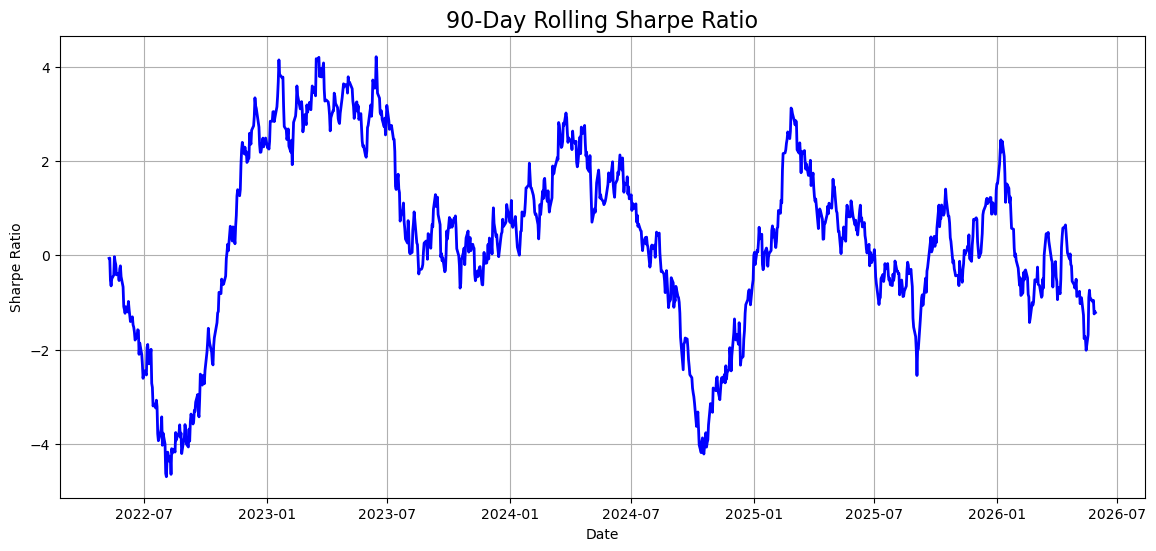

In [47]:
# create the chart and save the chart 

plt.figure(figsize=(14,6))

plt.plot(
    fund["date"],
    fund["rolling_sharpe"],
    color="blue",
    linewidth=2
)

plt.title("90-Day Rolling Sharpe Ratio", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

# save the chart
plt.savefig(
    "../charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# Save the rolling Sharpe data
fund.to_csv(
    "../reports/rolling_sharpe_report.csv",
    index=False
)

In [49]:
fund[["date","rolling_mean","rolling_std","rolling_sharpe"]].head(95)

,date,rolling_mean,rolling_std,rolling_sharpe
0,2022-01-03,NaN,NaN,NaN
1,2022-01-04,NaN,NaN,NaN
2,2022-01-05,NaN,NaN,NaN
3,2022-01-06,NaN,NaN,NaN
4,2022-01-07,NaN,NaN,NaN
...,...,...,...,...
90,2022-05-09,-0.000039,0.009489,-0.064787
91,2022-05-10,-0.000035,0.009485,-0.058880
92,2022-05-11,-0.000318,0.009475,-0.532521
93,2022-05-12,-0.000392,0.009588,-0.649005


In [50]:
# Task 3: Investor Cohort Analysis
    # Objective : Analyze investors based on the year they made their first investment.


# Load Transactions Data
transactions = pd.read_csv("../data/processed/clean_transactions.csv")

transactions.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [26]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [21]:
# Convert transaction date

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [22]:
# Find each investor's first investment date

first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
)

first_transaction.head()

investor_id
INV000001   2024-11-04
INV000002   2024-03-29
INV000003   2024-07-16
INV000004   2024-03-16
INV000005   2024-04-27
Name: transaction_date, dtype: datetime64[ns]

In [23]:
# Extract the cohort year

cohort_year = first_transaction.dt.year

cohort_year.head()

investor_id
INV000001    2024
INV000002    2024
INV000003    2024
INV000004    2024
INV000005    2024
Name: transaction_date, dtype: int32

In [24]:
# Add the cohort year to the transactions table

transactions["cohort_year"] = (
    transactions["investor_id"]
    .map(cohort_year)
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [25]:
# Create the Cohort Summary
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        Total_Investors=("investor_id", "nunique"),
        Total_Transactions=("investor_id", "count"),
        Total_Investment=("amount_inr", "sum"),
        Average_Investment=("amount_inr", "mean")
    )
    .reset_index()
)

cohort_summary

,cohort_year,Total_Investors,Total_Transactions,Total_Investment,Average_Investment
0,2024,4803,32499,3491125187,107422.541832
1,2025,197,279,30455243,109158.577061


In [26]:
# Save the report

os.makedirs("../reports", exist_ok=True)

cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("Cohort Analysis Report Saved Successfully!")

Cohort Analysis Report Saved Successfully!


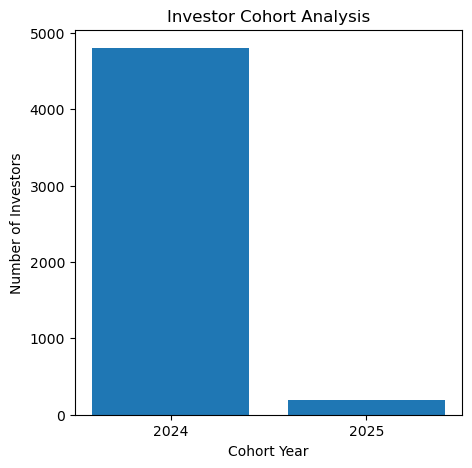

In [27]:
# Create a Cohort Chart
plt.figure(figsize=(5,5))

plt.bar(
    cohort_summary["cohort_year"].astype(str),
    cohort_summary["Total_Investors"]
)

plt.title("Investor Cohort Analysis")
plt.xlabel("Cohort Year")
plt.ylabel("Number of Investors")

# save the cohart chart
plt.savefig(
    "../charts/cohort_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Task 4: SIP Continuity Analysis
 # Objective: Identify investors who missed SIP payments.
   # --If the gap between two transactions is more than 35 days, we'll consider it a missed SIP.


In [29]:
# Sort the data

transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024


In [30]:
# Calculate the gap between transactions
transactions["days_gap"] = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

transactions.head(20)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,days_gap
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,69.0
17587,INV000002,2024-10-03,101207,Lumpsum,203094,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,12.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,112.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,114.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN


In [32]:
# Find investors with missed SIPs
missed_sip = transactions[
    transactions["days_gap"] > 35
]

missed_sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,days_gap
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,71.0
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,69.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,112.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,114.0


In [33]:
# Create a summary report
sip_summary = (
    missed_sip
    .groupby("investor_id")
    .agg(
        Missed_SIPs=("days_gap", "count"),
        Maximum_Gap=("days_gap", "max"),
        Average_Gap=("days_gap", "mean")
    )
    .reset_index()
)

sip_summary.head()

,investor_id,Missed_SIPs,Maximum_Gap,Average_Gap
0,INV000001,1,71.0,71.000000
1,INV000002,4,114.0,100.500000
2,INV000003,1,238.0,238.000000
3,INV000004,3,265.0,124.333333
4,INV000005,2,167.0,144.500000


In [34]:
# Save the report
sip_summary.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("SIP Continuity Report Saved Successfully!")

SIP Continuity Report Saved Successfully!


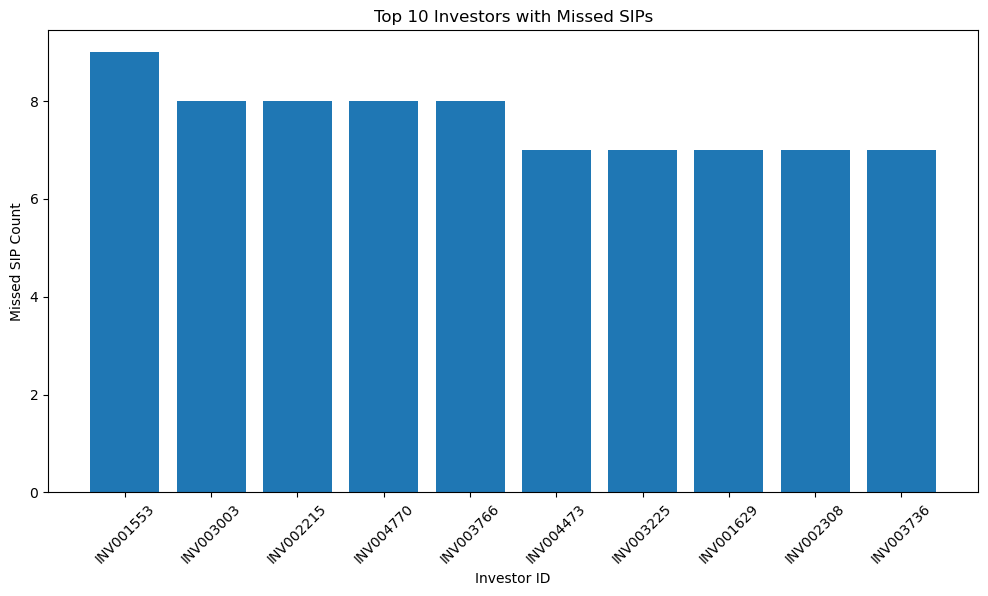

In [35]:
# Create a chart
plt.figure(figsize=(12,6))

top10 = sip_summary.sort_values(
    "Missed_SIPs",
    ascending=False
).head(10)

plt.bar(
    top10["investor_id"].astype(str),
    top10["Missed_SIPs"]
)

plt.title("Top 10 Investors with Missed SIPs")
plt.xlabel("Investor ID")
plt.ylabel("Missed SIP Count")

plt.xticks(rotation=45)

# save the chart
plt.savefig(
    "../charts/sip_continuity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [36]:
# Task 5: Fund Recommendation System
  # Objective: - Recommend the Top 5 Mutual Funds based on:

In [37]:
# load and read the data
performance = pd.read_csv("../data/processed/clean_performance.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly_flag,expense_ratio_valid
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False,True
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False,True
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False,True
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False,True
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False,True


In [38]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'anomaly_flag',
       'expense_ratio_valid'],
      dtype='object')


In [39]:
# Removing Missing Values 
recommend = performance.copy()

recommend = recommend.dropna(
    subset=[
        "return_3yr_pct",
        "sharpe_ratio",
        "expense_ratio_pct",
        "max_drawdown_pct"
    ]
)

recommend.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly_flag,expense_ratio_valid
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False,True
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False,True
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False,True
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False,True
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False,True


In [40]:
# Create a Fund Score
recommend["Fund_Score"] = (
    recommend["return_3yr_pct"] * 0.40 +
    recommend["sharpe_ratio"] * 0.30 -
    recommend["expense_ratio_pct"] * 0.15 -
    recommend["max_drawdown_pct"] * 0.15
)

In [41]:
# Why these weights?
# - 40% → 3-Year Return
# - 30% → Sharpe Ratio
# - 15% → Expense Ratio
# - 15% → Maximum Drawdown

# This is a simple but reasonable scoring approach.

In [42]:
# Recommend Top 5 Funds
top5 = (
    recommend
    .sort_values(
        "Fund_Score",
        ascending=False
    )
    .head(5)
)
top5[
    [
        "scheme_name",
        "fund_house",
        "category",
        "return_3yr_pct",
        "sharpe_ratio",
        "expense_ratio_pct",
        "Fund_Score"
    ]
]

,scheme_name,fund_house,category,return_3yr_pct,sharpe_ratio,expense_ratio_pct,Fund_Score
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,23.14,0.93,0.72,13.144
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,20.15,0.81,1.53,12.704
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,22.38,0.90,1.53,12.534
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.39,0.94,1.43,11.426
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,15.29,0.80,0.78,11.072


In [43]:
# Save the report
top5.to_csv(
    "../reports/fund_recommendation.csv",
    index=False
)

print("Fund Recommendation Report Saved Successfully!")

Fund Recommendation Report Saved Successfully!


<Figure size 1000x500 with 0 Axes>

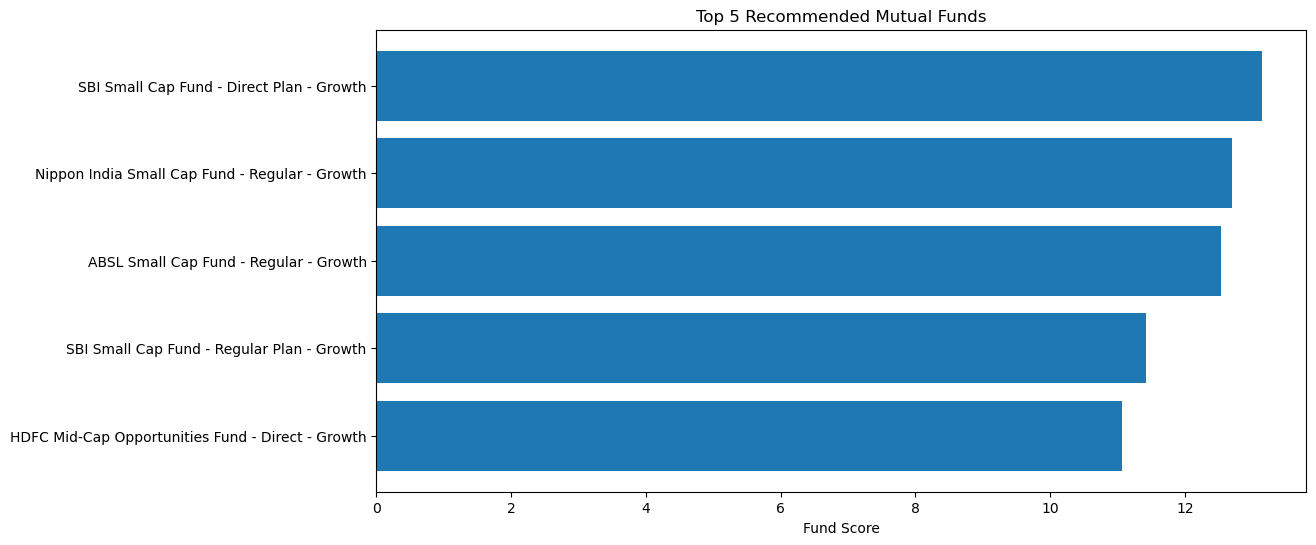

In [44]:
# Create a chart

plt.figure(figsize=(10,5))

# os.makedirs("../charts", exist_ok=True)
plt.figure(figsize=(12,6))

plt.barh(
    top5["scheme_name"],
    top5["Fund_Score"]
)

plt.title("Top 5 Recommended Mutual Funds")

plt.xlabel("Fund Score")

plt.gca().invert_yaxis()

# save the chart
plt.savefig(
    "../charts/top5_recommended_funds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# Task 6: Sector Concentration Analysis (HHI)

  #Objective: - Calculate the Herfindahl-Hirschman Index (HHI) to measure how concentrated each mutual fund's portfolio is.
  # Interpretation
  #   HHI	         Meaning
  # < 0.15	       Highly Diversified ✅
  # 0.15 – 0.25	   Moderately Concentrated
  # > 0.25	       Highly Concentrated

In [46]:
# Load Portfolio Holdings
holdings = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [47]:
print(holdings.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [48]:
# Create Portfolio Share
holdings = holdings.copy()

holdings["share"] = holdings["weight_pct"] / 100

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,share
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [50]:
# Calculate HHI
sector_hhi = (
    holdings
    .groupby("amfi_code")
    .agg(
        HHI=("share", lambda x: (x**2).sum())
    )
    .reset_index()
)

sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [51]:
# Create Risk Classification
def classify_hhi(hhi):

    if hhi < 0.15:
        return "Diversified"

    elif hhi < 0.25:
        return   "Moderately Concentrated"

    else:
        return   "Highly Concentrated"

sector_hhi["Portfolio_Type"] = (
    sector_hhi["HHI"]
    .apply(classify_hhi)
)

sector_hhi.head()

,amfi_code,HHI,Portfolio_Type
0,100016,0.139534,Diversified
1,100033,0.147592,Diversified
2,101206,0.129332,Diversified
3,101207,0.200700,Moderately Concentrated
4,102885,0.174709,Moderately Concentrated


In [53]:
# Save CSV
 # os.makedirs("../reports", exist_ok=True)

sector_hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

print("Sector HHI Report Saved Successfully!")

Sector HHI Report Saved Successfully!


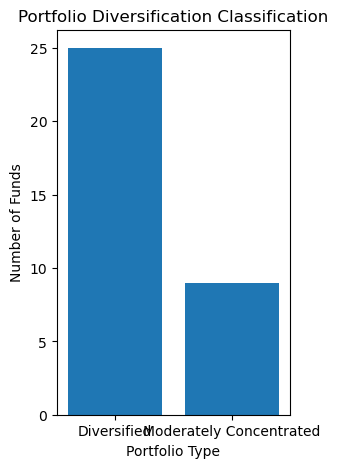

In [54]:
# Create Chart

summary = (
    sector_hhi["Portfolio_Type"]
    .value_counts()
)

plt.figure(figsize=(3,5))

plt.bar(
    summary.index,
    summary.values
)

plt.title("Portfolio Diversification Classification")

plt.xlabel("Portfolio Type")

plt.ylabel("Number of Funds")

# save the chart
plt.savefig(
    "../charts/sector_hhi_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()